In [1]:
import os
import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
from torch_geometric.data import Data

np.random.seed(314159)

In [2]:
device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


In [3]:

edge_path = '18k_lihc.npy'
node_path ='new_SC/200_node_network_18k_embeddings_with_single_cell.csv'

In [4]:
edge_list = np.load(edge_path, allow_pickle=True)
rows = np.array(edge_list)

protein1 = rows[:, 0]
protein2 = rows[:, 1]
combined_score = rows[:, 2].astype(np.float32)


all_proteins = np.unique(np.concatenate([protein1, protein2]))

protein_map = {
    protein: idx
    for idx, protein in enumerate(all_proteins)
}

print(f"Total nodes: {len(protein_map):,}")


mask = combined_score >= 700

protein1 = protein1[mask]
protein2 = protein2[mask]
combined_score = combined_score[mask]

print(f"Edges after filtering: {len(combined_score):,}")


protein1_idx = np.vectorize(protein_map.get)(protein1)
protein2_idx = np.vectorize(protein_map.get)(protein2)

edge_index = torch.tensor(
    np.vstack((protein1_idx, protein2_idx)),
    dtype=torch.long
)


edge_weight = torch.tensor(
    combined_score / 1000.0,
    dtype=torch.float32
)


from torch_geometric.utils import to_undirected

edge_index, edge_weight = to_undirected(
    edge_index,
    edge_weight,
    reduce="mean"
)

print(f"Final graph")
print(f" Nodes: {len(protein_map):,}")
print(f" Edges: {edge_index.shape[1]:,}")
print(f" Edge weights: {edge_weight.shape[0]:,}")

Total nodes: 10,976
Edges after filtering: 159,757
Final graph
 Nodes: 10,976
 Edges: 319,514
 Edge weights: 319,514


In [5]:
node_dataset = pd.read_csv(node_path, index_col=0)

n_before = len(node_dataset)
node_dataset = node_dataset[~node_dataset.index.duplicated(keep='first')]
n_dropped = n_before - len(node_dataset)
if n_dropped > 0:
    print(f'Dropped {n_dropped} ensembl duplicates')

node_dataset.sort_index(inplace=True)
node_dataset.reset_index(drop=False, inplace=True)
assert (node_dataset.index.to_numpy() == np.arange(len(node_dataset))).all()
assert not node_dataset.iloc[:, 0].duplicated().any(), "duplicates remain after dedup"


In [6]:
node_dataset

,ensembl,hpa_0,hpa_1,hpa_2,hpa_3,hpa_4,hpa_5,hpa_6,hpa_7,hpa_8,...,Hepatocyte (non-malignant),MAIT,Malignant hepatocyte,Naive T,Plasma B cell,SPARC+ endothelial,TREM2+ macrophage,TREM2+/MARCO+ macrophage,VEGFA+ macrophage,gda_score
0,ENSG00000000003,0.419887,-0.053613,0.382447,0.623703,0.053764,-0.032452,0.853239,-0.122219,0.226063,...,0.373672,0.015484,0.300531,0.010032,0.022955,0.232434,0.037488,0.103506,0.247886,NaN
1,ENSG00000000419,2.142819,-1.398136,0.074748,-1.091863,0.253802,0.016732,-0.359223,-0.185653,0.262858,...,0.269998,0.271238,0.503406,0.222237,0.209056,0.412570,0.275692,0.303213,0.314520,NaN
2,ENSG00000000457,1.110958,0.273468,0.814858,-0.243265,-0.281813,-0.068693,0.393298,-0.489433,-0.084377,...,0.034420,0.025202,0.047726,0.026220,0.019093,0.044141,0.017030,0.026554,0.015526,NaN
3,ENSG00000000938,1.687348,-0.584940,0.560584,-0.629926,0.096227,0.620006,-0.091872,-0.171348,-0.190687,...,0.014392,0.115392,0.007130,0.103001,0.008849,0.094195,0.302209,0.130135,0.207305,NaN
4,ENSG00000000971,1.964445,-0.893902,-0.756680,0.203450,-0.694858,1.438932,-0.483036,0.040794,-0.715785,...,1.737575,0.181584,1.963948,0.156257,0.330541,0.482767,0.170669,0.360614,0.249477,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10971,ENSG00000283154,0.857560,0.424845,0.435360,0.126368,-0.577634,-0.160169,0.349918,-0.497527,-0.016254,...,0.001993,0.001315,0.001954,0.001999,0.000582,0.052183,0.001123,0.000989,0.001382,NaN
10972,ENSG00000283632,1.106081,0.690618,0.256632,0.298403,-0.081344,-0.318818,-0.357324,0.398663,-0.660427,...,0.002362,0.001684,0.000235,0.000000,0.000000,0.143694,0.000523,0.001336,0.000000,NaN
10973,ENSG00000283706,0.916972,0.102102,0.700869,-0.553135,0.129830,0.028519,-0.421191,-0.220743,-0.271023,...,0.002469,0.000000,0.001772,0.000000,0.000000,0.000000,0.000140,0.000000,0.001133,NaN
10974,ENSG00000284194,0.979066,-1.282093,-0.774164,0.378746,0.157637,-0.435295,0.104130,0.031863,-0.111730,...,0.239777,0.087313,0.238357,0.100694,0.123440,0.112757,0.173618,0.136785,0.175327,NaN


In [7]:

label_name    = 'my_label'
pos_label_col = 'gda_score'

node_dataset[pos_label_col] = node_dataset[pos_label_col].fillna(0)
node_dataset[label_name] = pd.array(
    np.where(node_dataset[pos_label_col] != 0, 1, pd.NA),
    dtype='Int32'
)

def sample_negatives(PU_labels):
    num_pos  = (PU_labels == 1).sum()
    neg_inds = PU_labels[PU_labels.isna()].sample(num_pos, random_state=42).index
    return neg_inds

neg_label_inds = sample_negatives(node_dataset[label_name])
node_dataset.loc[neg_label_inds, label_name] = 0

print(node_dataset[label_name].value_counts())

my_label
1    226
0    226
Name: count, dtype: Int64


In [8]:

node_dataset = node_dataset.set_index(node_dataset.columns[0])

label_col = label_name
node_dataset[label_col] = node_dataset[label_col].astype('Int32')

if 'gda_score' in node_dataset.columns:
    node_dataset = node_dataset.drop(columns=['gda_score'])

node_feat_cols = node_dataset.columns[:-1].tolist()
node_data      = node_dataset[node_feat_cols + [label_col]]

feature_df = node_data[node_feat_cols].select_dtypes(include=[np.number]).fillna(0)
X = torch.tensor(feature_df.to_numpy(dtype=np.float32), dtype=torch.float32)

y = node_data[label_col].fillna(-1).astype('int')
y = torch.tensor(y.to_numpy(), dtype=torch.int64)

print('NaNs in X:', torch.isnan(X).sum().item())
print('Infs in X:', torch.isinf(X).sum().item())


NUM_HPA = 200
NUM_NET = 128

HPA_END = NUM_HPA
NET_END = HPA_END + NUM_NET
SC_END  = X.shape[1]


print(f'Feature blocks: HPA[0:{HPA_END}]'
      f'NET[{HPA_END}:{NET_END}] SC[{NET_END}:{SC_END}]')
print('Total features:', X.shape[1])

print('Column at HPA_END:', node_feat_cols[HPA_END])
print('Column at NET_END:', node_feat_cols[NET_END])

NaNs in X: 0
Infs in X: 0
Feature blocks: HPA[0:200]NET[200:328] SC[328:341]
Total features: 341
Column at HPA_END: network_0
Column at NET_END: ACTA2+ fibroblast


In [9]:
node_dataset

,hpa_0,hpa_1,hpa_2,hpa_3,hpa_4,hpa_5,hpa_6,hpa_7,hpa_8,hpa_9,...,Hepatocyte (non-malignant),MAIT,Malignant hepatocyte,Naive T,Plasma B cell,SPARC+ endothelial,TREM2+ macrophage,TREM2+/MARCO+ macrophage,VEGFA+ macrophage,my_label
ensembl,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.419887,-0.053613,0.382447,0.623703,0.053764,-0.032452,0.853239,-0.122219,0.226063,-0.131371,...,0.373672,0.015484,0.300531,0.010032,0.022955,0.232434,0.037488,0.103506,0.247886,<NA>
ENSG00000000419,2.142819,-1.398136,0.074748,-1.091863,0.253802,0.016732,-0.359223,-0.185653,0.262858,-0.041163,...,0.269998,0.271238,0.503406,0.222237,0.209056,0.412570,0.275692,0.303213,0.314520,<NA>
ENSG00000000457,1.110958,0.273468,0.814858,-0.243265,-0.281813,-0.068693,0.393298,-0.489433,-0.084377,-0.024996,...,0.034420,0.025202,0.047726,0.026220,0.019093,0.044141,0.017030,0.026554,0.015526,<NA>
ENSG00000000938,1.687348,-0.584940,0.560584,-0.629926,0.096227,0.620006,-0.091872,-0.171348,-0.190687,-0.293300,...,0.014392,0.115392,0.007130,0.103001,0.008849,0.094195,0.302209,0.130135,0.207305,<NA>
ENSG00000000971,1.964445,-0.893902,-0.756680,0.203450,-0.694858,1.438932,-0.483036,0.040794,-0.715785,-0.186413,...,1.737575,0.181584,1.963948,0.156257,0.330541,0.482767,0.170669,0.360614,0.249477,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000283154,0.857560,0.424845,0.435360,0.126368,-0.577634,-0.160169,0.349918,-0.497527,-0.016254,0.075846,...,0.001993,0.001315,0.001954,0.001999,0.000582,0.052183,0.001123,0.000989,0.001382,<NA>
ENSG00000283632,1.106081,0.690618,0.256632,0.298403,-0.081344,-0.318818,-0.357324,0.398663,-0.660427,-0.360964,...,0.002362,0.001684,0.000235,0.000000,0.000000,0.143694,0.000523,0.001336,0.000000,<NA>
ENSG00000283706,0.916972,0.102102,0.700869,-0.553135,0.129830,0.028519,-0.421191,-0.220743,-0.271023,-0.352592,...,0.002469,0.000000,0.001772,0.000000,0.000000,0.000000,0.000140,0.000000,0.001133,<NA>


In [10]:

from sklearn.model_selection import train_test_split

dup_ids = node_data.index[node_data.index.duplicated(keep=False)]
if len(dup_ids) > 0:
    raise ValueError(
        f"node_data has {node_data.index.duplicated().sum()} duplicate ensembl IDs "
        f"in its index (e.g. {sorted(set(dup_ids))[:5]}...). This will silently "
        f"corrupt id_to_idx / train-val-test masks. Deduplicate the node feature CSV "
        f"(e.g. node_dataset.drop_duplicates(subset='ensembl')) before proceeding."
    )

node_data_labeled = node_data[node_data[label_col].notna()]
node_data_labeled.to_csv('node_data_labeled_to_try2.csv', index=True)

X_myIDs = node_data_labeled.index.to_numpy()
labels  = node_data_labeled[label_col].to_numpy()

id_to_idx = {id_: idx for idx, id_ in enumerate(node_data.index)}
n_nodes   = len(node_data)

def make_masks(myIDs_train, myIDs_val, myIDs_test, n_nodes, id_to_idx):
    """Builds train/val/test boolean masks. The validation set is ONLY used for
    hyperparameter selection (e.g. learning rate sweeps) -- never for the final
    reported test metrics, to avoid overfitting hyperparameters to the test set."""
    train_idx = np.array([id_to_idx[i] for i in myIDs_train])
    val_idx   = np.array([id_to_idx[i] for i in myIDs_val])
    test_idx  = np.array([id_to_idx[i] for i in myIDs_test])

    train_mask = torch.zeros(n_nodes, dtype=torch.bool)
    val_mask   = torch.zeros(n_nodes, dtype=torch.bool)
    test_mask  = torch.zeros(n_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    return train_mask, val_mask, test_mask


def split_train_val_test(myIDs, labels, val_size=0.20, test_size=0.20):
    """60/20/20 split by default. Two-step stratified split: first carve off
    the test set, then split the remainder into train/val."""
    myIDs_trainval, myIDs_test, labels_trainval, labels_test = train_test_split(
        myIDs, labels, test_size=test_size, shuffle=True, stratify=labels
    )

    relative_val_size = val_size / (1.0 - test_size)
    myIDs_train, myIDs_val = train_test_split(
        myIDs_trainval, test_size=relative_val_size, shuffle=True, stratify=labels_trainval
    )
    return myIDs_train, myIDs_val, myIDs_test


myIDs_train_0, myIDs_val_0, myIDs_test_0 = split_train_val_test(X_myIDs, labels)
train_mask, val_mask, test_mask = make_masks(
    myIDs_train_0, myIDs_val_0, myIDs_test_0, n_nodes, id_to_idx
)

data = Data(x=X, y=y, edge_index=edge_index, edge_attr=edge_weight)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

num_classes  = 2
num_features = X.shape[1]

assert y.shape[0] == X.shape[0]
print(data)
print(f'Labeled: {len(X_myIDs)}  Pos: {(labels==1).sum()}  Neg: {(labels==0).sum()}')
print(f'Train: {len(myIDs_train_0)}  Val: {len(myIDs_val_0)}  Test: {len(myIDs_test_0)}')


Data(x=[10976, 341], edge_index=[2, 319514], edge_attr=[319514], y=[10976], train_mask=[10976], val_mask=[10976], test_mask=[10976])
Labeled: 452  Pos: 226  Neg: 226
Train: 270  Val: 91  Test: 91


In [11]:
import torch.nn.functional as F
from torch_geometric.nn import SGConv

class GNNModel(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes,
                 hidden_dense, GNN_conv_layer=SGConv, dropout_rate=0.1, K=4):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GNN_conv_layer(num_features, hidden_channels[0], K=K))
        for c1, c2 in zip(hidden_channels[:-1], hidden_channels[1:]):
            self.convs.append(GNN_conv_layer(c1, c2, K=K, cached=True))
        self.dense1    = torch.nn.Linear(hidden_channels[-1], hidden_dense)
        self.dense_out = torch.nn.Linear(hidden_dense, num_classes)
        self.dropout_rate = dropout_rate

    def forward(self, x, edge_index, edge_weight=None):
        for conv in self.convs:
            x = conv(x, edge_index, edge_weight=edge_weight)
            x = x.relu()
            x = F.dropout(x, p=self.dropout_rate, training=self.training)
        x = self.dense1(x).relu()
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        return self.dense_out(x)


class LitGNN(pl.LightningModule):
    def __init__(self, model_name, num_features, hidden_channels, num_classes,
                 hidden_dense, GNN_conv_layer, dropout_rate, K=2, lr=0.0001):
        super().__init__()
        self.save_hyperparameters(ignore=['GNN_conv_layer'])
        self.model_name = model_name
        self.lr         = lr
        self.model      = GNNModel(num_features, hidden_channels, num_classes,
                                   hidden_dense, GNN_conv_layer, dropout_rate, K=K)
        self.criterion  = torch.nn.CrossEntropyLoss()

    def forward(self, x, edge_index, edge_weight=None):
        return self.model(x, edge_index, edge_weight)

    def training_step(self, batch, batch_idx):
        out  = self(batch.x, batch.edge_index, batch.edge_attr)
        mask = batch.train_mask
        loss = self.criterion(out[mask], batch.y[mask])
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):

        out  = self(batch.x, batch.edge_index, batch.edge_attr)
        mask = batch.val_mask
        loss = self.criterion(out[mask], batch.y[mask])
        acc  = (out[mask].argmax(dim=1) == batch.y[mask]).float().mean()
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc',  acc,  on_epoch=True, prog_bar=True)
        return {'val_loss': loss, 'val_acc': acc}

    def test_step(self, batch, batch_idx):
        out  = self(batch.x, batch.edge_index, batch.edge_attr)
        mask = batch.test_mask
        loss = self.criterion(out[mask], batch.y[mask])
        acc  = (out[mask].argmax(dim=1) == batch.y[mask]).float().mean()
        self.log('test_loss', loss, on_epoch=True, prog_bar=True)
        self.log('test_acc',  acc,  on_epoch=True, prog_bar=True)
        return {'test_loss': loss, 'test_acc': acc}

    def on_test_epoch_end(self):
        pass

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0003)


In [12]:

from pytorch_lightning.callbacks import EarlyStopping, ModelSummary
from torch_geometric.loader import DataLoader
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

MAX_EPOCHS = 200
NUM_TRIALS = 25
mean_fpr = np.linspace(0, 1, 1000)

all_tprs = []
all_aucs = []
all_accs = []
all_precisions = []
all_recalls = []
all_f1s = []


all_models = []
all_test_masks = []

data = data.to(device)

for trial in range(1, NUM_TRIALS + 1):

    print(f"\n{'='*60}")
    print(f"Trial {trial}/{NUM_TRIALS}")
    print(f"{'='*60}")


    myIDs_train, myIDs_val, myIDs_test = split_train_val_test(X_myIDs, labels)

    t_mask, val_m, test_m = make_masks(
        myIDs_train,
        myIDs_val,
        myIDs_test,
        n_nodes,
        id_to_idx
    )

    data.train_mask = t_mask.to(device)
    data.val_mask   = val_m.to(device)
    data.test_mask  = test_m.to(device)


    model = LitGNN(
        model_name=f"trial_{trial}",
        num_features=num_features,
        hidden_channels=[128],
        num_classes=num_classes,
        hidden_dense=64,
        GNN_conv_layer=SGConv,
        dropout_rate=0.1,
        K=4,
        lr=0.0003,  
    ).to(device)


    trainer = pl.Trainer(
        accelerator="cpu",
        devices=1,
        precision="16-mixed",
        max_epochs=MAX_EPOCHS,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",   
                patience=100,
                mode="min"
            ),
            ModelSummary(max_depth=3)
        ],
        enable_checkpointing=False,
        logger=False,
        log_every_n_steps=10,
        enable_progress_bar=True
    )

    trainer.fit(
        model,
        train_dataloaders=DataLoader(
            [data],
            batch_size=1,
            shuffle=False
        ),
        val_dataloaders=DataLoader(
            [data],
            batch_size=1,
            shuffle=False
        )
    )


    model.eval()

    with torch.no_grad():
        logits = model(
            data.x,
            data.edge_index,
            data.edge_attr
        )

        probs = F.softmax(logits, dim=1)[:, 1]

    y_true = data.y[data.test_mask].detach().cpu().numpy()
    y_score = probs[data.test_mask].detach().cpu().numpy()
    y_pred = (y_score > 0.5).astype(int)

    unexpected = set(np.unique(y_true)) - {0, 1}
    if unexpected:
        raise ValueError(
            f"Trial {trial}: y_true contains unexpected label(s) {unexpected} "
            f"besides {{0, 1}} -- test_mask is selecting unlabeled (-1) rows. "
            f"This points to an id_to_idx / index misalignment upstream (see "
            f"the duplicate-ID check in the mask-building cell)."
        )

    auc = roc_auc_score(y_true, y_score)

    fpr, tpr, _ = roc_curve(y_true, y_score)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    interp_tpr[-1] = 1.0

    all_tprs.append(interp_tpr)
    all_aucs.append(auc)
    all_accs.append(accuracy_score(y_true, y_pred))
    all_precisions.append(
        precision_score(y_true, y_pred, zero_division=0)
    )
    all_recalls.append(
        recall_score(y_true, y_pred, zero_division=0)
    )
    all_f1s.append(
        f1_score(y_true, y_pred, zero_division=0)
    )

    all_models.append(model.eval().cpu())
    all_test_masks.append(data.test_mask.detach().cpu().clone())

    print(
        f"Trial {trial}: "
        f"AUC={auc:.4f} "
        f"Acc={all_accs[-1]:.4f} "
        f"Prec={all_precisions[-1]:.4f} "
        f"Rec={all_recalls[-1]:.4f} "
        f"F1={all_f1s[-1]:.4f}"
    )

/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
Using bfloat16 Automatic Mixed Precision (AMP)
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/vvlab/anaconda3/lib/pyt

Output()

/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Trial 1/25


...

/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

Trial 24: AUC=0.8502 Acc=0.7582 Prec=0.8000 Rec=0.6957 F1=0.7442

Trial 25/25


/home/vvlab/anaconda3/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=200` reached.


Trial 25: AUC=0.9024 Acc=0.7912 Prec=0.8250 Rec=0.7333 F1=0.7765


In [11]:
print(data)
print()

print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Features:", data.num_features)
print("Classes:", int(data.y.max()) + 1)

print("Edge index shape:", data.edge_index.shape)
print("Node feature shape:", data.x.shape)

Data(x=[12429, 214], edge_index=[2, 7989476], edge_attr=[7989476], y=[12429], train_mask=[12429], test_mask=[12429])

Nodes: 12429
Edges: 7989476
Features: 214
Classes: 2
Edge index shape: torch.Size([2, 7989476])
Node feature shape: torch.Size([12429, 214])


In [13]:

ARCHITECTURE = "SGConv" 
CANCER_TYPE  = "LIHC"   

import os
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

run_id = f"{ARCHITECTURE}_{CANCER_TYPE}"
npz_path = os.path.join(RESULTS_DIR, f"{run_id}.npz")

np.savez(
    npz_path,
    mean_fpr=mean_fpr,
    tprs=np.array(all_tprs),
    aucs=np.array(all_aucs),
    accs=np.array(all_accs),
    precisions=np.array(all_precisions),
    recalls=np.array(all_recalls),
    f1s=np.array(all_f1s),
)
print(f"Saved: {npz_path}")


summary_csv = os.path.join(RESULTS_DIR, "summary_results.csv")

def _ci95(values):
    values = np.array(values)
    sem = values.std() / np.sqrt(len(values))
    return 1.96 * sem

row = pd.DataFrame([{
    "architecture": ARCHITECTURE,
    "cancer_type":  CANCER_TYPE,
    "auc_mean": np.mean(all_aucs), "auc_std": np.std(all_aucs), "auc_ci95": _ci95(all_aucs),
    "acc_mean": np.mean(all_accs), "acc_std": np.std(all_accs), "acc_ci95": _ci95(all_accs),
    "f1_mean":  np.mean(all_f1s),  "f1_std":  np.std(all_f1s),  "f1_ci95":  _ci95(all_f1s),
    "n_trials": len(all_aucs),
}])

if os.path.exists(summary_csv):
    existing = pd.read_csv(summary_csv)
    existing = existing[~((existing.architecture == ARCHITECTURE) & (existing.cancer_type == CANCER_TYPE))]
    combined = pd.concat([existing, row], ignore_index=True)
else:
    combined = row

combined.to_csv(summary_csv, index=False)
print(f"Updated: {summary_csv}")
combined

Saved: results/SGConv_LIHC.npz
Updated: results/summary_results.csv


,architecture,cancer_type,auc_mean,auc_std,auc_ci95,acc_mean,acc_std,acc_ci95,f1_mean,f1_std,f1_ci95,n_trials
0,GraphSAGE,LIHC,0.843826,0.042791,0.016774,0.748571,0.050532,0.019809,0.758232,0.043338,0.016988,25
1,GCN,LIHC,0.876135,0.025597,0.010034,0.785495,0.038082,0.014928,0.795723,0.033088,0.012971,25
2,SGConv,LIHC,0.872850,0.032238,0.012637,0.792088,0.036236,0.014205,0.788739,0.035253,0.013819,25


In [14]:
from scipy import stats

print('\n================ FINAL RESULTS ================')
print(f'AUC      : {np.mean(all_aucs):.4f} ± {np.std(all_aucs):.4f}')
print(f'Accuracy : {np.mean(all_accs):.4f} ± {np.std(all_accs):.4f}')
print(f'Precision: {np.mean(all_precisions):.4f} ± {np.std(all_precisions):.4f}')
print(f'Recall   : {np.mean(all_recalls):.4f} ± {np.std(all_recalls):.4f}')
print(f'F1-score : {np.mean(all_f1s):.4f} ± {np.std(all_f1s):.4f}')

print('\n================ STATISTICAL TESTS ================')
t_auc, p_auc = stats.ttest_1samp(all_aucs, 0.5)
t_f1,  p_f1  = stats.ttest_1samp(all_f1s, 0.0)
print(f'AUC vs random (0.5): t={t_auc:.3f}, p={p_auc:.5f}')
print(f'F1  vs zero   (0.0): t={t_f1:.3f},  p={p_f1:.5f}')


================ FINAL RESULTS ================
AUC      : 0.8729 ± 0.0322
Accuracy : 0.7921 ± 0.0362
Precision: 0.8052 ± 0.0498
Recall   : 0.7761 ± 0.0500
F1-score : 0.7887 ± 0.0353

================ STATISTICAL TESTS ================
AUC vs random (0.5): t=56.660, p=0.00000
F1  vs zero   (0.0): t=109.609,  p=0.00000


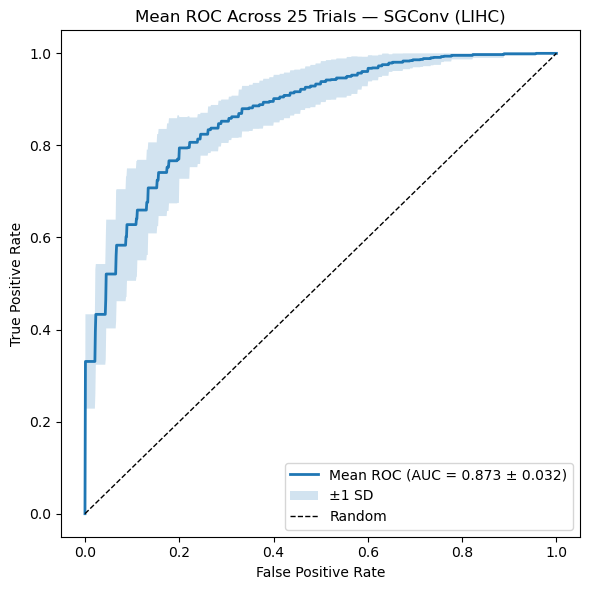

Mean AUC = 0.8729 ± 0.0322


In [15]:
import matplotlib.pyplot as plt

mean_tpr = np.clip(np.mean(all_tprs, axis=0), 0, 1)
std_tpr  = np.std(all_tprs, axis=0)
mean_auc = np.mean(all_aucs)
std_auc  = np.std(all_aucs)

plt.figure(figsize=(6, 6))
plt.plot(mean_fpr, mean_tpr, lw=2,
         label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')
plt.fill_between(mean_fpr,
                 np.clip(mean_tpr - std_tpr, 0, 1),
                 np.clip(mean_tpr + std_tpr, 0, 1),
                 alpha=0.2, label='±1 SD')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mean ROC Across 25 Trials — SGConv (LIHC)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Mean_ROC_SGConv_LIHC.tiff', dpi=1200, format='tiff', bbox_inches='tight')
plt.show()
print(f'Mean AUC = {mean_auc:.4f} ± {std_auc:.4f}')

In [16]:
all_probs = []

with torch.no_grad():
    for trial_model in all_models:
        trial_model.eval()
        logits = trial_model(data.x.cpu(), data.edge_index.cpu(), data.edge_attr.cpu())
        probs  = F.softmax(logits, dim=1).numpy()
        all_probs.append(probs)

all_probs  = np.stack(all_probs)         
mean_probs = all_probs.mean(axis=0)
std_probs  = all_probs.std(axis=0)

prob_df = pd.DataFrame(
    mean_probs,
    index=node_data.index,
    columns=[f'class_{i}_mean' for i in range(mean_probs.shape[1])]
)
for i in range(std_probs.shape[1]):
    prob_df[f'class_{i}_std'] = std_probs[:, i]

prob_df['true_label'] = data.y.cpu().numpy()
prob_df.to_csv('predicted_probabilities_sgconv_lihc.csv')
print('Saved: predicted_probabilities_sgconv_lihc.csv')

Saved: predicted_probabilities_sgconv_lihc.csv


      AUC_mean   AUC_std  ACC_mean   ACC_std   F1_mean    F1_std
FULL  0.872850  0.032238  0.792088  0.036236  0.788739  0.035253
HPA   0.821043  0.054262  0.662418  0.052978  0.512141  0.115218
NET   0.845874  0.040307  0.774505  0.037700  0.771684  0.035061
SC    0.828657  0.040207  0.712967  0.044861  0.633084  0.077550

================ ABLATION SIGNIFICANCE (paired t-test vs FULL) ================
 HPA: AUC drop = +0.0518  t=6.259  p=0.00000
 NET: AUC drop = +0.0270  t=4.711  p=0.00009
  SC: AUC drop = +0.0442  t=8.462  p=0.00000

================ MODULE IMPORTANCE (95% bootstrap CI, n=5000 resamples of 25 trials) ================
     mean_drop    ci_low   ci_high
HPA   0.051807  0.038048  0.069739
NET   0.026976  0.016193  0.037778
SC    0.044193  0.034667  0.054377


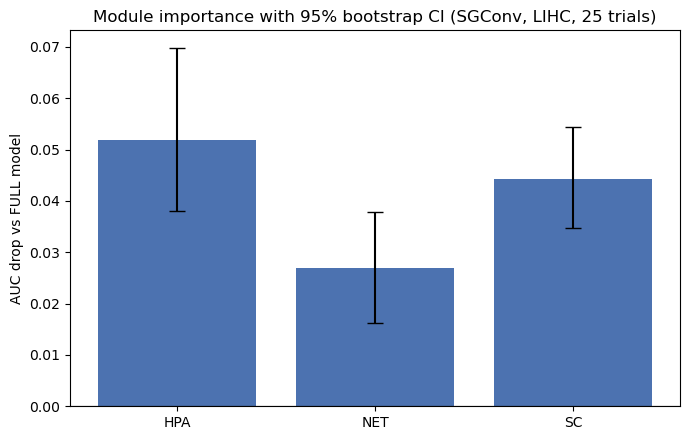

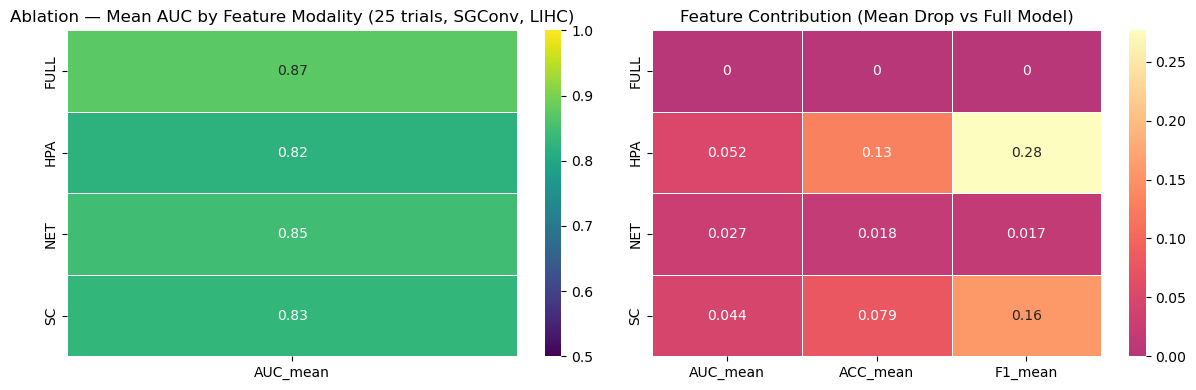

In [17]:
import seaborn as sns
from scipy import stats as sstats
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

def get_feature_matrix(X_tensor, ablate=None):
    X_new = X_tensor.clone()
    if ablate == 'HPA':   X_new[:, :HPA_END]       = 0
    elif ablate == 'NET': X_new[:, HPA_END:NET_END] = 0
    elif ablate == 'SC':  X_new[:, NET_END:SC_END]  = 0
    return X_new

ablation_modes = [None, 'HPA', 'NET', 'SC']
X_cpu = data.x.detach().cpu()
edge_index_cpu = data.edge_index.detach().cpu()
edge_attr_cpu  = data.edge_attr.detach().cpu()
y_cpu = data.y.detach().cpu()


per_trial = {mode: [] for mode in ablation_modes}

for trial_model, trial_test_mask in zip(all_models, all_test_masks):
    trial_model.eval()
    y_true_abl = y_cpu[trial_test_mask].numpy()

    for mode in ablation_modes:
        X_ablate = get_feature_matrix(X_cpu, mode)
        with torch.no_grad():
            logits  = trial_model(X_ablate, edge_index_cpu, edge_attr_cpu)
            y_score = F.softmax(logits, dim=1)[:, 1].numpy()[trial_test_mask]
        y_pred = (y_score > 0.5).astype(int)
        per_trial[mode].append({
            'AUC': roc_auc_score(y_true_abl, y_score),
            'ACC': accuracy_score(y_true_abl, y_pred),
            'F1':  f1_score(y_true_abl, y_pred, zero_division=0)
        })

summary_rows = {}
for mode in ablation_modes:
    label = mode if mode else 'FULL'
    aucs = [d['AUC'] for d in per_trial[mode]]
    accs = [d['ACC'] for d in per_trial[mode]]
    f1s  = [d['F1']  for d in per_trial[mode]]
    summary_rows[label] = {
        'AUC_mean': np.mean(aucs), 'AUC_std': np.std(aucs),
        'ACC_mean': np.mean(accs), 'ACC_std': np.std(accs),
        'F1_mean':  np.mean(f1s),  'F1_std':  np.std(f1s),
    }

df_abl = pd.DataFrame(summary_rows).T.loc[['FULL', 'HPA', 'NET', 'SC']]
df_abl.to_csv('ablation_results_sgconv_lihc.csv')
print(df_abl)

print('\n================ ABLATION SIGNIFICANCE (paired t-test vs FULL) ================')
full_aucs = [d['AUC'] for d in per_trial[None]]
sig_rows = {}
paired_diffs = {}  
for mode in ['HPA', 'NET', 'SC']:
    mode_aucs = [d['AUC'] for d in per_trial[mode]]
    diffs = np.array(full_aucs) - np.array(mode_aucs)
    paired_diffs[mode] = diffs
    t_stat, p_val = sstats.ttest_rel(full_aucs, mode_aucs)
    sig_rows[mode] = {'AUC_drop': diffs.mean(), 't': t_stat, 'p': p_val}
    print(f'{mode:>4}: AUC drop = {diffs.mean():+.4f}  t={t_stat:.3f}  p={p_val:.5f}')

df_sig = pd.DataFrame(sig_rows).T
df_sig.to_csv('ablation_significance_sgconv_lihc.csv')


n_boot = 5000
rng = np.random.default_rng(0)
boot_rows = {}
for mode, diffs in paired_diffs.items():
    boot_means = [rng.choice(diffs, size=len(diffs), replace=True).mean() for _ in range(n_boot)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    boot_rows[mode] = {'mean_drop': diffs.mean(), 'ci_low': ci_low, 'ci_high': ci_high}

df_boot = pd.DataFrame(boot_rows).T
df_boot.to_csv('module_importance_bootstrap_ci_sgconv_lihc.csv')
print('\n================ MODULE IMPORTANCE (95% bootstrap CI, n=5000 resamples of 25 trials) ================')
print(df_boot)

fig, ax = plt.subplots(figsize=(7, 4.5))
modules = list(paired_diffs.keys())
means   = df_boot.loc[modules, 'mean_drop'].values
err_low  = means - df_boot.loc[modules, 'ci_low'].values
err_high = df_boot.loc[modules, 'ci_high'].values - means
ax.bar(modules, means, yerr=[err_low, err_high], capsize=6, color='#4C72B0')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('AUC drop vs FULL model')
ax.set_title('Module importance with 95% bootstrap CI (SGConv, LIHC, 25 trials)')
plt.tight_layout()
plt.savefig('Module_Importance_Bootstrap_CI_SGConv_LIHC.tiff', dpi=1200, format='tiff', bbox_inches='tight')
plt.show()

# ---- Heatmaps (mean AUC by module, and drop across all metrics) ----
importance = df_abl.loc['FULL', ['AUC_mean', 'ACC_mean', 'F1_mean']] - df_abl[['AUC_mean', 'ACC_mean', 'F1_mean']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(df_abl[['AUC_mean']], annot=True, cmap='viridis',
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=axes[0])
axes[0].set_title('Ablation — Mean AUC by Feature Modality (25 trials, SGConv, LIHC)')
sns.heatmap(importance, annot=True, cmap='magma',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Feature Contribution (Mean Drop vs Full Model)')
plt.tight_layout()
plt.savefig('Ablation_SGConv_LIHC.tiff', dpi=1200, format='tiff', bbox_inches='tight')
plt.show()

In [20]:
delta_auc = results['FULL']['AUC'] - results['SC']['AUC']
delta_f1  = results['FULL']['F1']  - results['SC']['F1']
delta_acc = results['FULL']['ACC'] - results['SC']['ACC']

print(f'Delta AUC (FULL vs no-SC): {delta_auc:+.4f}')
print(f'Delta F1  (FULL vs no-SC): {delta_f1:+.4f}')
print(f'Delta Acc (FULL vs no-SC): {delta_acc:+.4f}')

Delta AUC (FULL vs no-SC): +0.0796
Delta F1  (FULL vs no-SC): +0.2498
Delta Acc (FULL vs no-SC): +0.1667
